In [ ]:
%load_ext autoreload
%autoreload 2

import os
import tempfile
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, knn_graph

from cluster_energy import partition_loss_numpy


In [2]:
import colapy


def extract_nucleons_numpy(particles: list[Any]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Match ``datasets.data_io.extract_nucleons_numpy``: ``pos`` is ``(N, 4)`` as ``(t, x, y, z)`` (fm/c, fm)."""
    pos, mom, is_proton = [], [], []
    for p in particles:
        if p.pdg_code == 2212:
            mom.append([p.momentum.e, p.momentum.x, p.momentum.y, p.momentum.z])
            pos.append([p.position.t, p.position.x, p.position.y, p.position.z])
            is_proton.append(True)
        elif p.pdg_code == 2112:
            mom.append([p.momentum.e, p.momentum.x, p.momentum.y, p.momentum.z])
            pos.append([p.position.t, p.position.x, p.position.y, p.position.z])
            is_proton.append(False)
    if not pos:
        return np.zeros((0, 4), np.float64), np.zeros((0, 4), np.float64), np.zeros((0,), bool)
    return np.asarray(pos, np.float64), np.asarray(mom, np.float64), np.asarray(is_proton, bool)


class W(colapy.WriterBase):
    events = []

    def __init__(self, **kwargs):
        self.events.clear()

    def __call__(self, event_data):
        self.events.append(event_data)

def try_make_urqmd_event_generator():
    CONFIG = """
<?xml version="1.0" encoding="UTF-8" ?>
<program>
    <generator name="URQMDGenerator"
        pro="197 79"
        tar="197 79"
        nev="1"
        imp="5."
        elb="100."
        tim="200 200"
        generated_config_file="input_file"/>
    <writer name="PythonWriter" class="W"/>
</program>
"""

    def gen_one():
        with tempfile.NamedTemporaryFile(mode="w", suffix=".xml", delete_on_close=False) as tmp:
            tmp.write(CONFIG)
            tmp.close()
            rm = colapy.RunManager().load_module("COLA-Py").load_module("COLA_UrQMD").load_config(tmp.name)
            rm.run(1)
            if os.path.exists("input_file"):
                os.remove("input_file")
        if not W.events:
            return np.zeros((0, 4)), np.zeros((0, 4)), np.zeros((0,), bool)
        ev = W.events[-1]
        pos, mom, isp = extract_nucleons_numpy(ev.particles)
        return pos, mom, isp

    return gen_one


URQMD_GEN = try_make_urqmd_event_generator()


## Baseline clustering: Coalescence


In [ ]:
from pathlib import Path

import numpy as np

from cluster_energy import partition_loss_numpy
from models import (
    Q_CUT_MEVC,
    R_CUT_FM,
    baseline_clusters_numpy,
    load_valid_events_from_pkl,
)


def baseline_labels_and_partition(
    pos: np.ndarray,
    mom: np.ndarray,
    isp: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[list[int]]]:
    """Align lengths; return (pos_n, mom_n, isp_n, baseline_partition)."""
    n0 = min(pos.shape[0], mom.shape[0], isp.shape[0])
    pos_n = np.asarray(pos[:n0], dtype=np.float64)
    mom_n = np.asarray(mom[:n0], dtype=np.float64)
    isp_n = np.asarray(isp[:n0], dtype=bool)
    n = pos_n.shape[0]
    if n < 2:
        return pos_n, mom_n, isp_n, []
    part = baseline_clusters_numpy(pos_n, mom_n, list(range(n)), R_CUT_FM, Q_CUT_MEVC)
    return pos_n, mom_n, isp_n, part


def labels_from_partition(n: int, part: list[list[int]]) -> np.ndarray:
    lab = np.zeros(n, dtype=np.int32)
    for ci, c in enumerate(part):
        for j in c:
            lab[j] = ci
    return lab


def benchmark_baseline_on_events(
    events: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
) -> None:
    l_list: list[float] = []
    for pos, mom, isp in events:
        n = pos.shape[0]
        if n < 2:
            continue
        part = baseline_clusters_numpy(pos, mom, list(range(n)), R_CUT_FM, Q_CUT_MEVC)
        l_list.append(float(partition_loss_numpy(pos, mom, isp, part)))
    if not l_list:
        print("No events with n≥2 in slice.")
        return
    l_mev = np.asarray(l_list, dtype=np.float64)
    n_in = len(events)
    print(
        f"Baseline (slice len={n_in}, evaluated n = {len(l_list)}): "
        f"partition loss = {l_mev.mean():.1f} ± {l_mev.std():.1f} MeV"
    )


_VALID_EVENTS = load_valid_events_from_pkl(Path("datasets") / "urqmd_nucleons_1k" / "dataset.pkl")


In [4]:
benchmark_baseline_on_events(_VALID_EVENTS[:64])


Baseline (slice len=64, evaluated n = 64): partition loss = -165.1 ± 229.2 MeV


## Baseline clustering: Visualization


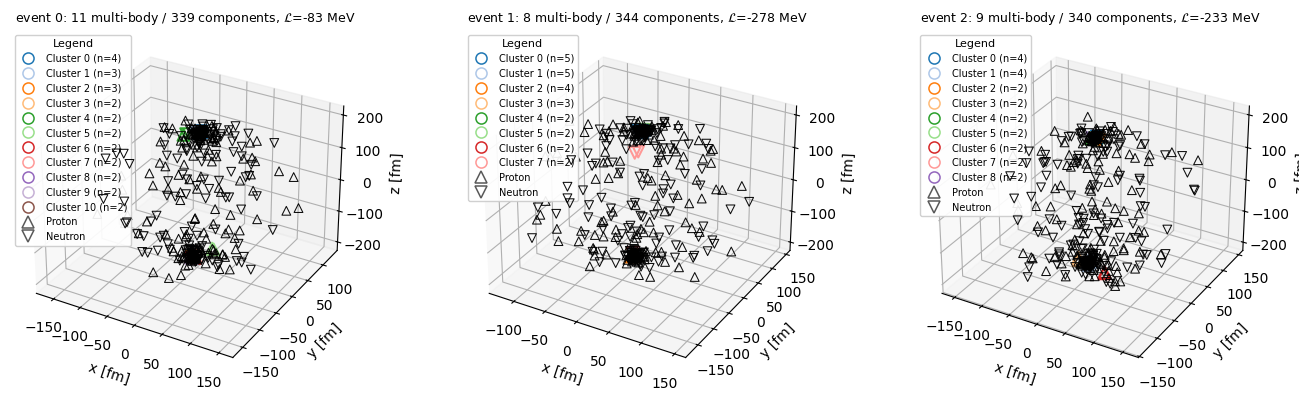

In [5]:
from matplotlib.lines import Line2D


def _tab20_sample(i: int) -> tuple:
    """Distinct ``tab20`` color for multi-body cluster rank ``i`` (cycles every 20)."""
    cmap = plt.get_cmap("tab20")
    n = int(getattr(cmap, "N", 20))
    t = (float(i % n) + 0.5) / float(n)
    return cmap(t)


def plot_baseline_clusterings_preview(
    events: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
    *,
    seed: int = 0,
) -> None:
    if not events:
        print("No events to visualize.")
        return
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(events), size=len(events), replace=False)
    ncols = min(3, len(events))
    nrows = int(np.ceil(len(events) / ncols))
    fig = plt.figure(figsize=(4.6 * ncols, 4.0 * nrows))
    z_back, z_front = 1, 25
    s_single, lw_single = 40, 0.75
    s_multi, lw_multi = 72, 1.45
    edge_w_leg = 1.1
    for j, ii in enumerate(idx):
        pos, mom, isp = events[int(ii)]
        pos_n, mom_n, isp_n, part = baseline_labels_and_partition(pos, mom, isp)
        n = pos_n.shape[0]
        ax = fig.add_subplot(nrows, ncols, j + 1, projection="3d")
        if n < 2 or not part:
            ax.set_title(f"event {int(ii)}: n<2 or empty", fontsize=9)
            continue
        lab = labels_from_partition(n, part)
        cluster_sizes = np.array([len(c) for c in part], dtype=int)
        singleton = cluster_sizes[lab] == 1
        L_part = float(partition_loss_numpy(pos_n, mom_n, isp_n, part))
        pr = isp_n
        ne = ~isp_n
        multi_ids = sorted(ci for ci, c in enumerate(part) if len(c) > 1)
        ci_to_rgba = {ci: _tab20_sample(rank) for rank, ci in enumerate(multi_ids)}
        # Background: singletons (draw first, smaller).
        for mask, marker in ((pr, "^"), (ne, "v")):
            ms = mask & singleton
            if np.any(ms):
                ax.scatter(
                    pos_n[ms, 0],
                    pos_n[ms, 1],
                    pos_n[ms, 2],
                    facecolors="none",
                    edgecolors="black",
                    marker=marker,
                    s=s_single,
                    linewidths=lw_single,
                    alpha=0.95,
                    zorder=z_back,
                    depthshade=True,
                )
        # Foreground: multi-body clusters (draw last, larger, no depth fade).
        for mask, marker in ((pr, "^"), (ne, "v")):
            mm = mask & ~singleton
            if np.any(mm):
                idx_mm = np.flatnonzero(mm)
                ec = np.array([ci_to_rgba[int(lab[i])] for i in idx_mm], dtype=float)
                ax.scatter(
                    pos_n[mm, 0],
                    pos_n[mm, 1],
                    pos_n[mm, 2],
                    facecolors="none",
                    edgecolors=ec,
                    marker=marker,
                    s=s_multi,
                    linewidths=lw_multi,
                    alpha=1.0,
                    zorder=z_front,
                    depthshade=False,
                )
        ax.set_xlabel("x [fm]")
        ax.set_ylabel("y [fm]")
        ax.set_zlabel("z [fm]")
        n_multi = int(np.sum(cluster_sizes > 1))
        ax.set_title(
            rf"event {int(ii)}: {n_multi} multi-body / {len(part)} components, "
            rf"$\mathcal{{L}}$={L_part:.0f} MeV",
            fontsize=9,
        )
        handles: list[Line2D] = []
        for ci in multi_ids:
            rgba = ci_to_rgba[ci]
            handles.append(
                Line2D(
                    [0],
                    [0],
                    linestyle="none",
                    marker="o",
                    markersize=8.0,
                    markerfacecolor="none",
                    markeredgecolor=rgba,
                    markeredgewidth=edge_w_leg,
                    label=f"Cluster {ci} (n={len(part[ci])})",
                )
            )
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="^",
                markersize=8.0,
                markerfacecolor="none",
                markeredgecolor="0.35",
                markeredgewidth=edge_w_leg,
                label="Proton",
            )
        )
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="v",
                markersize=8.0,
                markerfacecolor="none",
                markeredgecolor="0.35",
                markeredgewidth=edge_w_leg,
                label="Neutron",
            )
        )
        ax.legend(
            handles=handles,
            loc="upper left",
            fontsize=7,
            framealpha=0.92,
            title="Legend",
            title_fontsize=8,
        )
    plt.tight_layout()
    plt.show()


plot_baseline_clusterings_preview(_VALID_EVENTS[:3], seed=1)


## GAT + pairwise edge affinity + Bernoulli REINFORCE

## Supervised on baseline: KNN graph


In [ ]:
from pathlib import Path

from models import load_valid_events_from_pkl

TB_NOTEBOOK_ROOT = Path("runs") / "notebook"

DATA_PKL = Path("datasets") / "urqmd_nucleons_1k" / "dataset.pkl"
events = load_valid_events_from_pkl(DATA_PKL) if DATA_PKL.exists() else []

## Inline TensorBoard

Run the next cell **once** before (or between) training cells. While loops are running, use TensorBoard’s **refresh** in the embedded UI to pull new scalars. Logs use the same directory as ``TB_NOTEBOOK_ROOT`` above: ``runs/notebook``.


In [ ]:
%tensorboard

In [7]:
from models import AffinityGraphConfig, AffinityGraphEnv, CoalescenceHeuristicModel, GATAffinityPolicy, GAT_NODE_IN_DIM
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import make_event_sampler

SUP_CFG = AffinityGraphConfig(k_nn=6, graph_kind="knn")
supervised_env = AffinityGraphEnv(SUP_CFG, CoalescenceHeuristicModel())
supervised_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    running_norm=False,
)
rng_sup = np.random.default_rng(42)
sampler_sup = make_event_sampler(events=events, rng=rng_sup, fallback_urqmd=None)

tb_sup_knn = TensorBoardHistoryLogger(TB_NOTEBOOK_ROOT / "supervised_knn6")
try:
    sup_hist = train_supervised_edges(
        supervised_policy,
        supervised_env,
        sampler_sup,
        steps=80,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=20,
        on_update=tb_sup_knn.log_supervised,
    )
finally:
    tb_sup_knn.close()
print(
    "last gap MeV:",
    sup_hist["pretrain_gap"][-1],
    "| recall@0.5:",
    sup_hist["pretrain_pos_recall_05"][-1],
)


SupEdges: 100%|██████████| 80/80 [00:39<00:00,  2.00it/s, bce=0.0267, L_pol=-1.54, L_base=-0.155, gap=-1.38, posRec=0.97, pOn=0.0344]       

last gap MeV: -1382.9470324650806 | recall@0.5: 0.9703125


## Supervised on baseline: radius graph (r = 1.15)

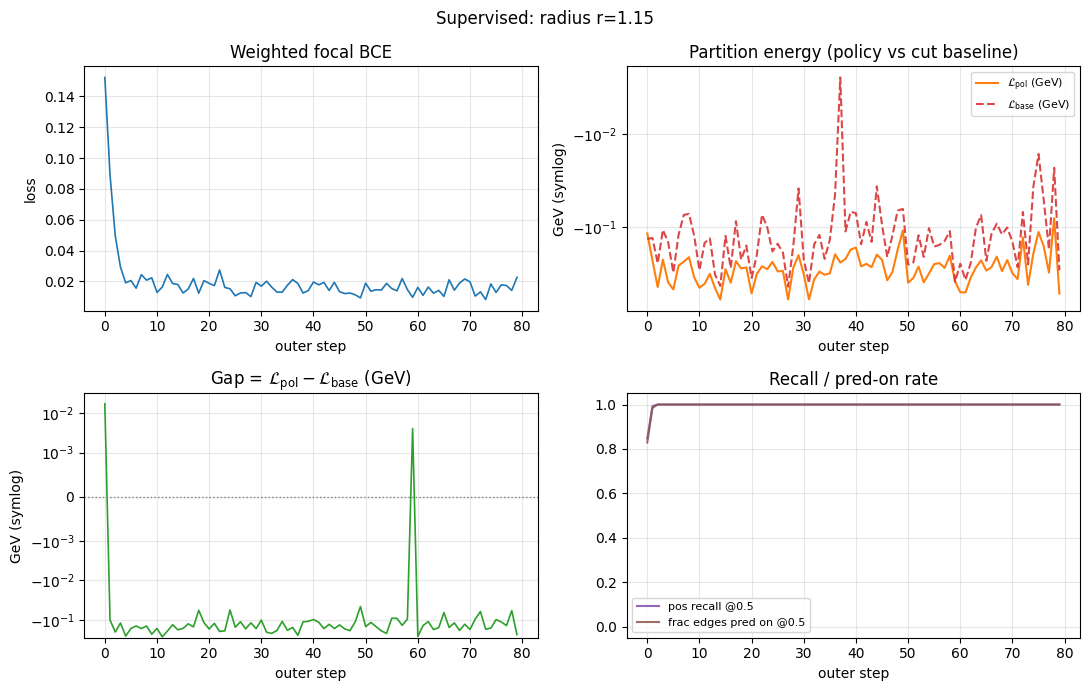

SupEdges: 100%|██████████| 80/80 [01:06<00:00,  1.19it/s, bce=0.0227, L_pol=-0.527, L_base=-0.295, gap=-0.232, posRec=1, pOn=1]

radius r=1.15 | last gap MeV: -231.65447383954574 | recall@0.5: 1.0


In [8]:
from models import AffinityGraphConfig, AffinityGraphEnv, CoalescenceHeuristicModel, GATAffinityPolicy, GAT_NODE_IN_DIM
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import make_event_sampler

RADIUS_CFG = AffinityGraphConfig(graph_kind="radius", radius_norm=1.15)
radius_env = AffinityGraphEnv(RADIUS_CFG, CoalescenceHeuristicModel())
radius_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    running_norm=False,
)
rng_radius = np.random.default_rng(43)
sampler_radius = make_event_sampler(events=events, rng=rng_radius, fallback_urqmd=None)

tb_sup_radius = TensorBoardHistoryLogger(TB_NOTEBOOK_ROOT / "supervised_radius_115")
try:
    radius_hist = train_supervised_edges(
        radius_policy,
        radius_env,
        sampler_radius,
        steps=80,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=20,
        on_update=tb_sup_radius.log_supervised,
    )
finally:
    tb_sup_radius.close()
print(
    "radius r=1.15 | last gap MeV:",
    radius_hist["pretrain_gap"][-1],
    "| recall@0.5:",
    radius_hist["pretrain_pos_recall_05"][-1],
)


## Supervised on baseline: full graph

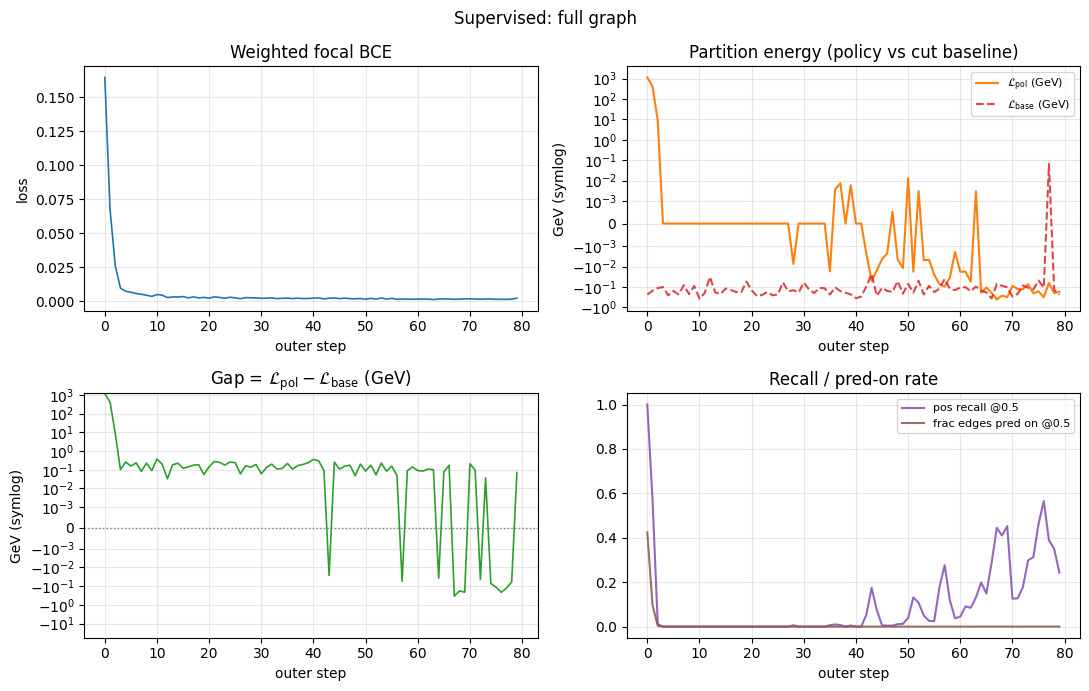

SupEdges: 100%|██████████| 80/80 [02:37<00:00,  1.96s/it, bce=0.0023, L_pol=-0.171, L_base=-0.242, gap=0.0708, posRec=0.243, pOn=9.26e-5]

full graph | last gap MeV: 70.83717645057601 | recall@0.5: 0.24343674945297586


In [9]:
from models import AffinityGraphConfig, AffinityGraphEnv, CoalescenceHeuristicModel, GATAffinityPolicy, GAT_NODE_IN_DIM
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import make_event_sampler

FULL_CFG = AffinityGraphConfig(graph_kind="full")
full_env = AffinityGraphEnv(FULL_CFG, CoalescenceHeuristicModel())
full_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    running_norm=False,
)
rng_full = np.random.default_rng(44)
sampler_full = make_event_sampler(events=events, rng=rng_full)

tb_sup_full = TensorBoardHistoryLogger(TB_NOTEBOOK_ROOT / "supervised_full")
try:
    full_hist = train_supervised_edges(
        full_policy,
        full_env,
        sampler_full,
        steps=80,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=15,
        on_update=tb_sup_full.log_supervised,
    )
finally:
    tb_sup_full.close()
print(
    "full graph | last gap MeV:",
    full_hist["pretrain_gap"][-1],
    "| recall@0.5:",
    full_hist["pretrain_pos_recall_05"][-1],
)


## RL: REINFORCE

Same starting point as A2C/PPO: load a **supervised** (or other) checkpoint into `policy_rl` via `fresh_policy_from_file()`, use matching **`env_rl`** (`RL_KNN`). Edit `PRETRAINED_POLICY_CKPT`, `RL_KNN`, and optionally `RL_CLUSTER_DISSOLVE_ENERGY_THRESHOLD_MEV` (post-CC cluster energy dissolve; `None` = off) in the setup cell below.


In [10]:
import numpy as np
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from models import (
    AffinityGraphConfig,
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
)
from training.reinforce import train_reinforce
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import make_event_sampler

RNG = np.random.default_rng(0)
sample_event = make_event_sampler(_VALID_EVENTS, RNG)


In [11]:
PRETRAINED_POLICY_CKPT = Path(".cache/sup_knn6_datasets__urqmd_nucleons_1k__dataset.pt")
RL_KNN = 6


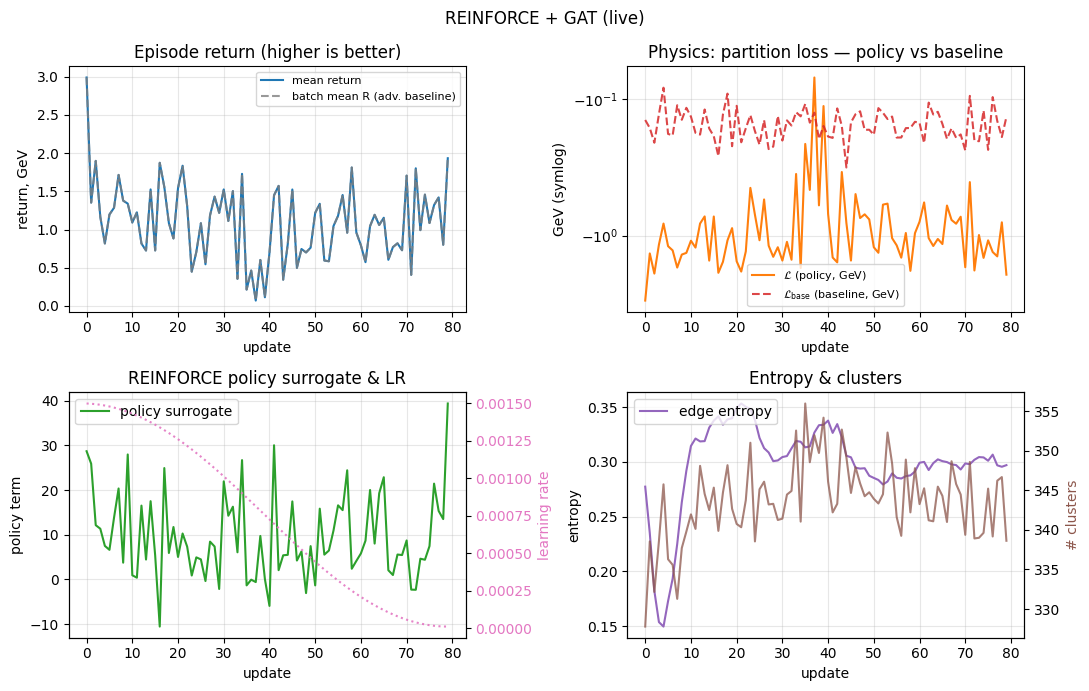

REINFORCE: 100%|██████████| 80/80 [03:55<00:00,  2.94s/it, pi=39.4, H=0.297, lr=1e-5, Rmean=1.93, G=1.93, L_pol=-1.93, L_base=-0.136, n_cl=339]


In [12]:
env = AffinityGraphEnv(
    AffinityGraphConfig(
        k_nn=RL_KNN,
        cluster_dissolve_energy_threshold_mev=0,
    ),
    CoalescenceHeuristicModel(),
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=1,
    running_norm=False,
)
policy.load_state_dict(torch.load(PRETRAINED_POLICY_CKPT, map_location="cpu")['state_dict'], strict=True)

N_REINFORCE_UPDATES = 80
REINFORCE_LR = 1.5e-3

train_opt = optim.Adam(policy.parameters(), lr=REINFORCE_LR)
eta_min = min(1e-5, max(1e-10, float(REINFORCE_LR) * 0.05))
train_sched = CosineAnnealingLR(train_opt, T_max=N_REINFORCE_UPDATES, eta_min=eta_min)

tb_rf = TensorBoardHistoryLogger(TB_NOTEBOOK_ROOT / "reinforce")
try:
    history = train_reinforce(
        policy,
        env,
        sample_event,
        optimizer=train_opt,
        lr_scheduler=train_sched,
        n_updates=N_REINFORCE_UPDATES,
        episodes_per_update=24,
        ent_coef=0.001,
        max_grad_norm=1.2,
        policy_coef=0.08,
        rl_action_mode="bernoulli",
        on_update=tb_rf.log_reinforce,
    )
finally:
    tb_rf.close()


## RL: A2C

In [13]:
from models import GATAffinityActorCritic
from training.a2c import train_actor_critic, warm_start_value_head
from training.tensorboard import TensorBoardHistoryLogger

N_VALUE_WARMUP = 12
EPISODES_PER_UPDATE_RL = 24


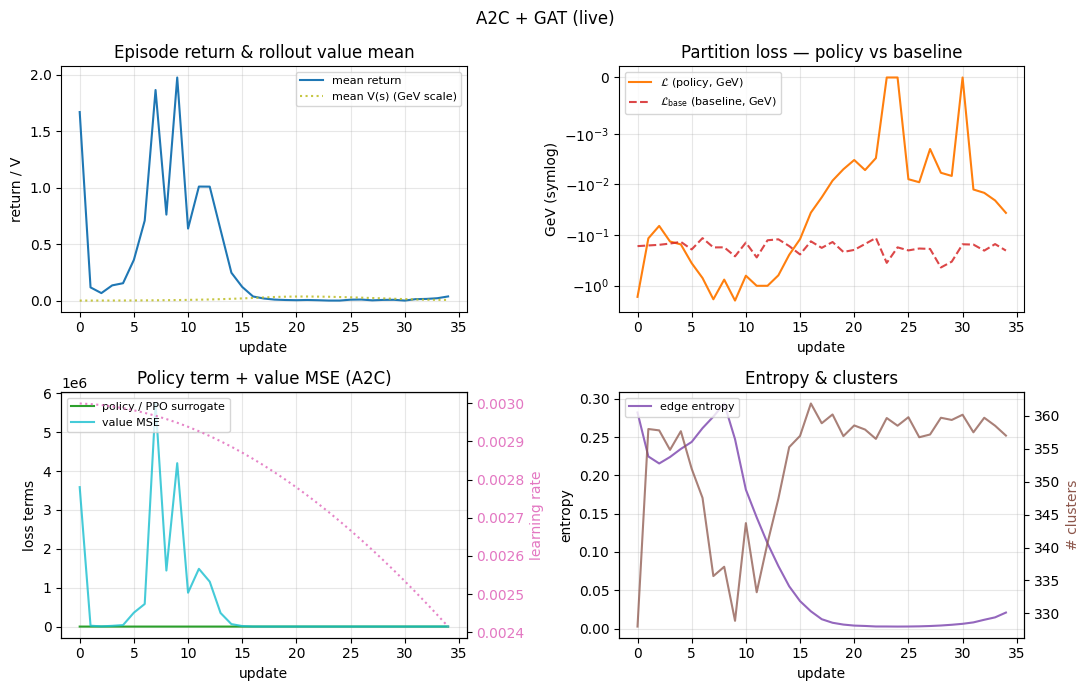

A2C:  29%|██▉       | 35/120 [01:26<03:30,  2.47s/it, pi=0.293, Vloss=6.07e+3, H=0.0283, lr=0.00238, Vroll=0.00578, G=0.0718, L_pol=-0.0718, L_base=-0.194, n_cl=357]


KeyboardInterrupt: 

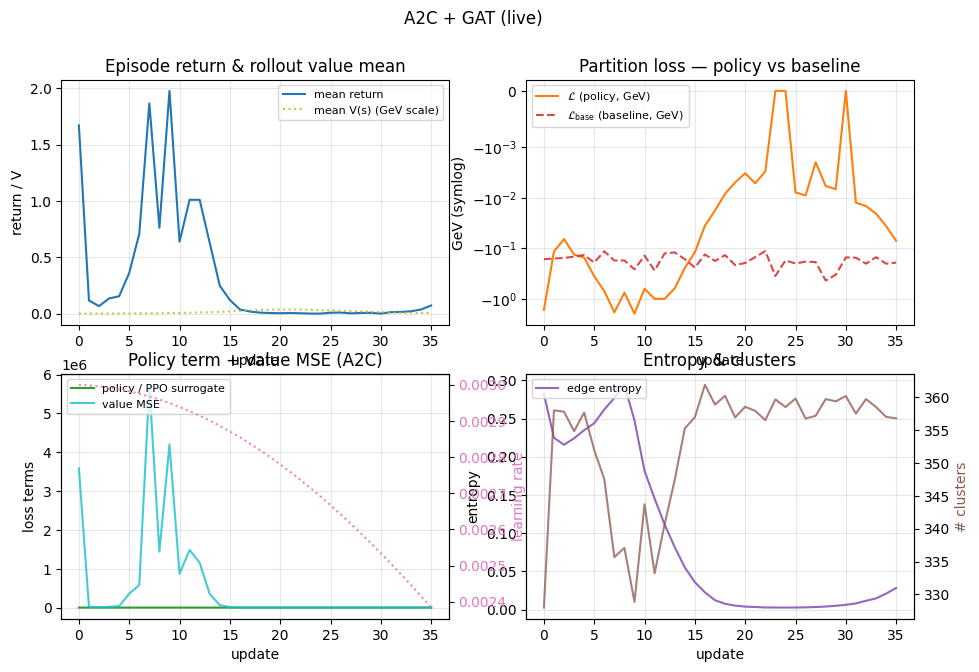

In [ ]:
env = AffinityGraphEnv(
    AffinityGraphConfig(
        k_nn=RL_KNN,
        cluster_dissolve_energy_threshold_mev=0,
    ),
    CoalescenceHeuristicModel(),
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=1,
    running_norm=False,
)
policy.load_state_dict(torch.load(PRETRAINED_POLICY_CKPT, map_location="cpu")['state_dict'], strict=True)

ac = GATAffinityActorCritic(policy)

N_A2C_UPDATES = 120
lr_a2c = 3e-4
a2c_opt = optim.Adam(ac.parameters(), lr=lr_a2c)
eta_min_a2c = min(1e-5, max(1e-8, lr_a2c * 0.05))
a2c_sched = CosineAnnealingLR(a2c_opt, T_max=N_A2C_UPDATES, eta_min=eta_min_a2c)

tb_a2c = TensorBoardHistoryLogger(TB_NOTEBOOK_ROOT / "a2c")
try:
    history_a2c = train_actor_critic(
        ac,
        env,
        sample_event,
        optimizer=a2c_opt,
        lr_scheduler=a2c_sched,
        n_updates=N_A2C_UPDATES,
        episodes_per_update=EPISODES_PER_UPDATE_RL,
        ent_coef=0.012,
        value_coef=0.5,
        max_grad_norm=1.2,
        policy_coef=0.08,
        center_adv=True,
        rl_action_mode="bernoulli",
        on_update=lambda h: tb_a2c.log_actor_critic(h, algo="a2c"),
    )
finally:
    tb_a2c.close()


### RL: PPO

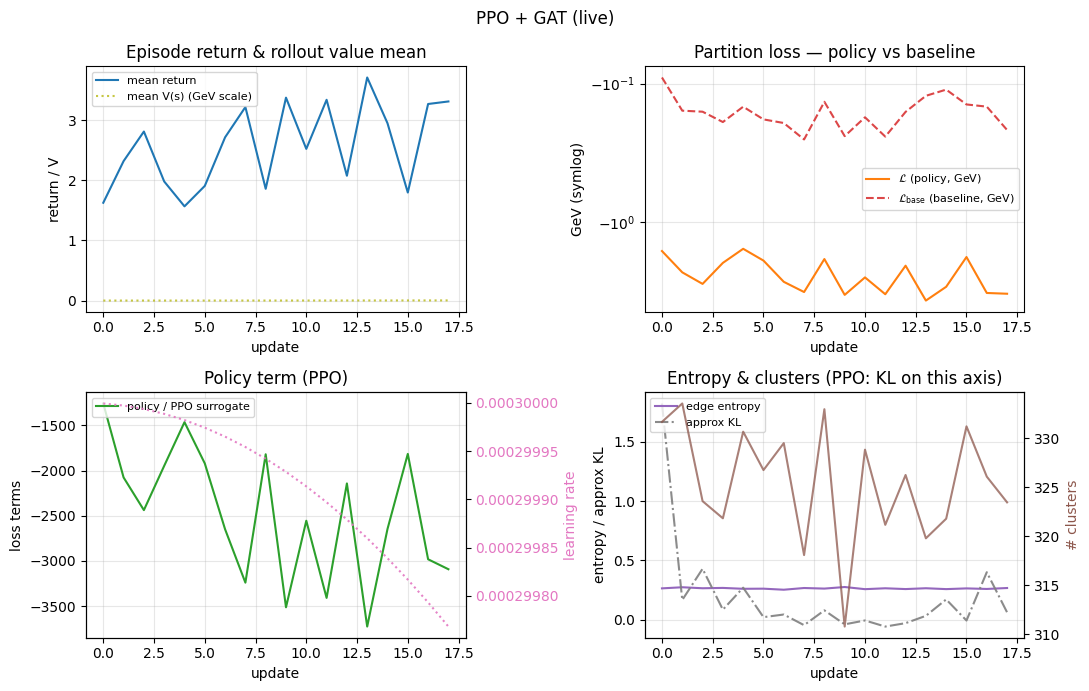

PPO:   2%|▏         | 18/1000 [00:57<52:56,  3.23s/it, pi=-3.09e+3, Vloss=1.4e+7, kl=0.0608, clip=0.604, H=0.266, lr=0.0003, Vroll=0.00267, G=3.31, L_pol=-3.31, L_base=-0.217, n_cl=323]

In [ ]:
from training.ppo import train_ppo
from training.tensorboard import TensorBoardHistoryLogger


env = AffinityGraphEnv(
    AffinityGraphConfig(
        k_nn=RL_KNN,
        cluster_dissolve_energy_threshold_mev=0,
    ),
    CoalescenceHeuristicModel(),
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=1,
    running_norm=False,
)
policy.load_state_dict(torch.load(PRETRAINED_POLICY_CKPT, map_location="cpu")['state_dict'], strict=True)

ac_ppo = GATAffinityActorCritic(policy)

N_PPO_UPDATES = 1000
lr_ppo = 3e-4
ppo_opt = optim.Adam(ac_ppo.parameters(), lr=lr_ppo)
eta_min_ppo = min(1e-5, max(1e-8, lr_ppo * 0.05))
ppo_sched = CosineAnnealingLR(ppo_opt, T_max=N_PPO_UPDATES, eta_min=eta_min_ppo)

tb_ppo = TensorBoardHistoryLogger(TB_NOTEBOOK_ROOT / "ppo")
try:
    history_ppo = train_ppo(
        ac_ppo,
        env,
        sample_event,
        optimizer=ppo_opt,
        lr_scheduler=ppo_sched,
        n_updates=N_PPO_UPDATES,
        episodes_per_update=EPISODES_PER_UPDATE_RL,
        ppo_epochs=4,
        clip_range=0.15,
        value_coef=0.5,
        ent_coef=0.02,
        policy_coef=0.12,
        max_grad_norm=1.2,
        normalize_advantage=False,
        rl_action_mode="bernoulli",
        on_update=lambda h: tb_ppo.log_actor_critic(h, algo="ppo"),
    )
finally:
    tb_ppo.close()


## Rollout visualization (deterministic policy, one event)